# Exam Score Analysis - Machine Learning

In this notebook, we will explore and compare students' exam scores, perform data analysis, and examine how different factors like study habits, sleep, and attendance affect performance.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib
import kagglehub
from kagglehub import KaggleDatasetAdapter


file_path = "Exam_Score_Prediction.csv"
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "kundanbedmutha/exam-score-prediction-dataset",
    file_path
)

C:\Users\janah\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
C:\Users\janah\AppData\Local\Temp\ipykernel_35644\3832102211.py:16: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [44]:
print("First 5 rows:")
display(df.head())

print("\nDataset info:")
df.info()

First 5 rows:


,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


In [ ]:
print("\nDataset description:")
display(df.describe())


Dataset description:


,student_id,age,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,facility_rating,exam_difficulty,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.504600,20.473300,4.007604,70.017365,0.849400,7.00856,1.996600,1.998200,1.892000,62.513225
std,5773.654959,2.284458,2.308313,17.282262,0.357667,1.73209,0.815673,0.813652,0.703179,18.908491
min,1.000000,17.000000,0.080000,40.600000,0.000000,4.10000,1.000000,1.000000,1.000000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,1.000000,5.50000,1.000000,1.000000,1.000000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,1.000000,7.00000,2.000000,2.000000,2.000000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,1.000000,8.50000,3.000000,3.000000,2.000000,76.300000
max,20001.000000,24.000000,7.910000,99.400000,1.000000,9.90000,3.000000,3.000000,3.000000,100.000000


In [ ]:

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\nUnique values in '{col}': {df[col].unique()}")


ordinal_mapping = {
    'sleep_quality': {'poor': 1, 'average': 2, 'good': 3},
    'facility_rating': {'low': 1, 'medium': 2, 'high': 3},
    'exam_difficulty': {'easy': 1, 'moderate': 2, 'hard': 3},
    'internet_access': {'no': 0, 'yes': 1}
}

for col, val_map in ordinal_mapping.items():
    if col in df.columns:
        df[col] = df[col].map(val_map)

# One-Hot Encoding
df_final = pd.get_dummies(df, columns=['gender', 'course', 'study_method'], drop_first=True)


First 5 rows:


,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB

Dataset description:


,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.504600,20.473300,4.007604,70.017365,7.00856,62.513225
std,5773.654959,2.284458,2.308313,17.282262,1.73209,18.908491
min,1.000000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,20001.000000,24.000000,7.910000,99.400000,9.90000,100.000000



Unique values in 'gender': ['male' 'other' 'female']

Unique values in 'course': ['diploma' 'bca' 'b.sc' 'b.tech' 'bba' 'ba' 'b.com']

Unique values in 'internet_access': ['yes' 'no']

Unique values in 'sleep_quality': ['poor' 'average' 'good']

Unique values in 'study_method': ['coaching' 'online videos' 'mixed' 'self-study' 'group study']

Unique values in 'facility_rating': ['low' 'medium' 'high']

Unique values in 'exam_difficulty': ['hard' 'moderate' 'easy']


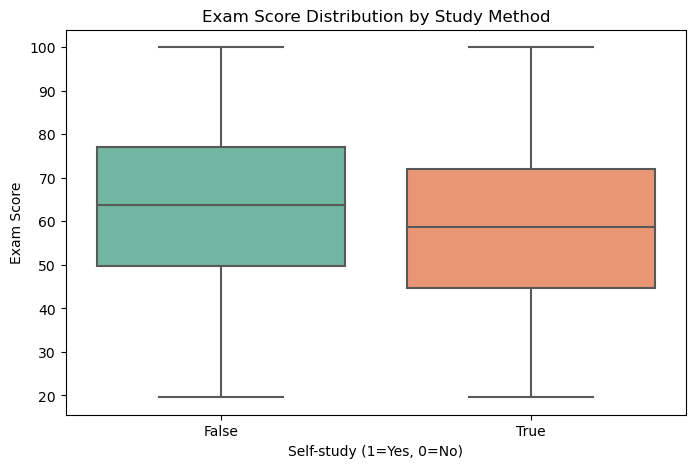

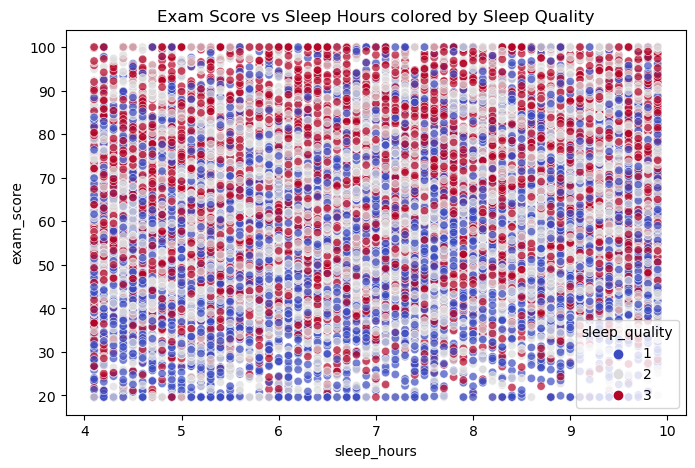

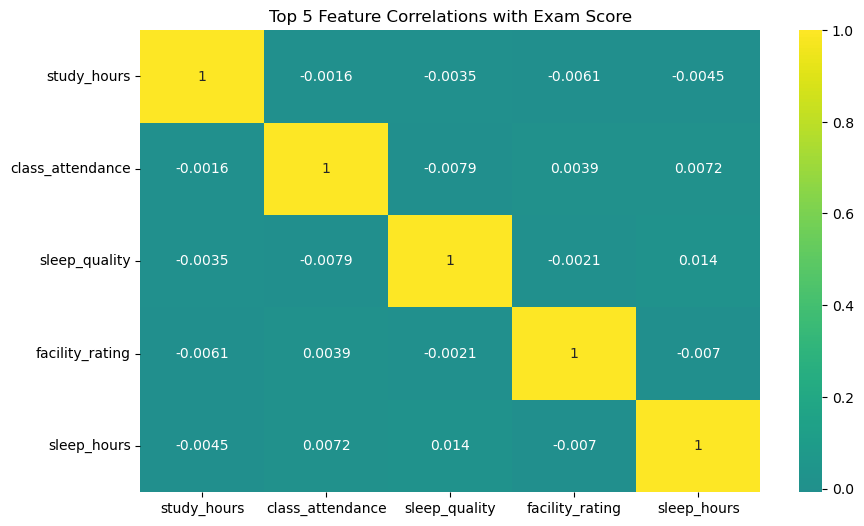

In [ ]:

plt.figure(figsize=(8,5))
sns.boxplot(data=df_final, x='study_method_self-study', y='exam_score', palette='Set2')
plt.title('Exam Score Distribution by Study Method')
plt.xlabel('Self-study (1=Yes, 0=No)')
plt.ylabel('Exam Score')
plt.show()


plt.figure(figsize=(8,5))
sns.scatterplot(data=df_final, x='sleep_hours', y='exam_score', hue='sleep_quality', palette='coolwarm', alpha=0.7)
plt.title('Exam Score vs Sleep Hours colored by Sleep Quality')
plt.show()


plt.figure(figsize=(10,6))
corr = df_final.corr()
top_corr = corr['exam_score'].abs().sort_values(ascending=False)[1:6].index
sns.heatmap(df_final[top_corr].corr(), annot=True, cmap='viridis', center=0)
plt.title('Top 5 Feature Correlations with Exam Score')
plt.show()


### a) Boxplot: Exam Score distribution by Study Method
- Students who follow **Self-study** tend to have higher average scores.
- The plot shows variance within each study method group and highlights outliers.

### b) Scatterplot: Exam Score vs Sleep Hours (colored by Sleep Quality)
- Positive relationship: more sleep and good sleep quality leads to higher exam scores.
- Students with `good sleep` consistently achieve higher scores.

### c) Heatmap: Top 5 features correlated with Exam Score
- Most influential features: `study_hours`, `class_attendance`, `sleep_hours`, `sleep_quality`, `facility_rating`.
- Shows that study hours, attendance, and sleep quality positively correlate with exam performance.

In [ ]:

y = df_final['exam_score']


linear_features = ['study_hours', 'class_attendance', 'sleep_hours', 'sleep_quality', 'facility_rating', 'study_method_self-study']
X_linear = df_final[linear_features]
X_train_lin, X_test_lin, y_train, y_test = train_test_split(X_linear, y, test_size=0.2, random_state=42)


X_forest = df_final.drop(['exam_score', 'student_id'], axis=1)
X_train_rf, X_test_rf, _, _ = train_test_split(X_forest, y, test_size=0.2, random_state=42)


models = {
    "Linear Regression (Subset)": LinearRegression(),
    "Ridge (Subset)": Ridge(alpha=1.0), 
    "Lasso (Subset)": Lasso(alpha=0.1),
    "Decision Tree (Full)": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest (Full)": RandomForestRegressor(n_estimators=100, random_state=42)
}



results = []

for name, model in models.items():
    if "(Subset)" in name:
        X_train_current, X_test_current = X_train_lin, X_test_lin
    else:
        X_train_current, X_test_current = X_train_rf, X_test_rf
    
    cv_scores = cross_val_score(model, X_train_current, y_train, cv=5, scoring='r2')
    model.fit(X_train_current, y_train)
    test_score = model.score(X_test_current, y_test)
    
    results.append({
        "Model": name,
        "CV R2 Mean": cv_scores.mean(),
        "Test R2": test_score
    })

results_df = pd.DataFrame(results).sort_values(by="Test R2", ascending=False)
display(results_df)

best_model_entry = max(results, key=lambda x: x['Test R2'])
print("\nBEST MODEL PERFORMANCE")
print(f"Model Name: {best_model_entry['Model']}")
print(f"Test R2 Score: {best_model_entry['Test R2']:.4f}")
print(f"Cross-Validation R2: {best_model_entry['CV R2 Mean']:.4f}")

,Model,CV R2 Mean,Test R2
0,Linear Regression (Subset),0.705056,0.708061
1,Ridge (Subset),0.705056,0.708060
2,Lasso (Subset),0.704794,0.707464
4,Random Forest (Full),0.685137,0.687346
3,Decision Tree (Full),0.600687,0.605370



BEST MODEL PERFORMANCE
Model Name: Linear Regression (Subset)
Test R2 Score: 0.7081
Cross-Validation R2: 0.7051


### Model Performance Summary
- The table shows the performance of all trained models on the **training set (CV R²)** and **test set (Test R²)**.
- **Linear Regression (Subset)** achieved the highest test performance with **R² ≈ 0.708**, closely followed by Ridge and Lasso.
- Random Forest (Full) performed slightly worse (**R² ≈ 0.687**), while Decision Tree (Full) had the lowest R² (**≈ 0.605**), indicating underfitting.
- **Key Insight:** A simple linear model using the most important features (study hours, sleep, attendance, etc.) is sufficient to explain ~70% of exam score variance.


In [46]:
# GridSearch + K-Fold With Random Forest

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring='r2',
    cv=5,   # K-Fold
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_rf, y_train)

best_rf = grid_search.best_estimator_
final_pred = best_rf.predict(X_test_rf)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Final Tuned Test R2: {r2_score(y_test, final_pred):.4f}")
print(f"Final Tuned MAE: {mean_absolute_error(y_test, final_pred):.2f}")


lin_model = LinearRegression()
lin_model.fit(X_train_lin, y_train)
joblib.dump(lin_model, "linear_regression_model.pkl")

loaded_model = joblib.load("linear_regression_model.pkl")
y_pred = loaded_model.predict(X_test_lin)
score = loaded_model.score(X_test_lin, y_test)
print("R2 on test set using saved model:", score)


Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 500}
Final Tuned Test R2: 0.7008
Final Tuned MAE: 8.39
R2 on test set using saved model: 0.708061313859327


- Tuning improved Random Forest performance slightly, making it a strong model for predicting exam scores with all features included.  
- The final test set R² is 0.701 and MAE is 8.39, indicating reasonable accuracy and error margins.


## 🔹 Key Insights
1. Increasing **study hours and class attendance** improves exam scores.  
2. **Good sleep quality** is positively associated with higher scores.  
3. **Self-study** is generally more effective than other study methods.  
4. Random Forest with GridSearch + K-Fold gave best prediction performance.  
5. Linear models are accurate on selected features and can be reused via saved model.